# First data exploration

This notebook contains the code to explore various datasets for the RSApp project.

Datasets include:
- a fire history (nr fires per year per pixel) image, with a raster for each year from 2001 to 2015, provided by [Global Forest Watch](https://data.globalforestwatch.org/datasets/indonesia-fire-history/about)
- **MODIS fire alerts** in Indonesia from 2001 to 2025, from NASA FIRMS
- shapefile of peatland areas from Global Forest Watch (not good according to Sasa) - maybe compare to PEATMAP and Global Peat Map
- 2021 global **land cover** map from ESA, cropped to Indonesia for classification into cropland vs. forest vs. shrubland
- global peatland map (published 2022) from [Global Peatlands](https://globalpeatlands.org/new-online-global-peatland-map-asian-peatlands-story-map-presenting-best-peatlands-mapping)

# Wildfire history Indonesia

In [1]:
import rasterio
import xarray as xr
import numpy as np
from rasterio.plot import show

ModuleNotFoundError: No module named 'rasterio'

In [38]:
import rioxarray

### Explore single raster (2001)

In [3]:
path = "input-data/fire-history-data/kd2001_rgb.tif"
fh_2001 = rasterio.open(path)

In [15]:
# Basic info on the raster dataset
print("Number of bands:", fh_2001.count)
print("Width (nr of pixels):", fh_2001.width)
print("Height (nr of pixels):", fh_2001.height)
print("CRS:", fh_2001.crs)
print("Bounding coordinates:", fh_2001.bounds)

Number of bands: 3
Width (nr of pixels): 9133
Height (nr of pixels): 3306
CRS: EPSG:4326
Bounding coordinates: BoundingBox(left=95.3435, bottom=-10.7195, right=141.0085, top=5.810500000000001)


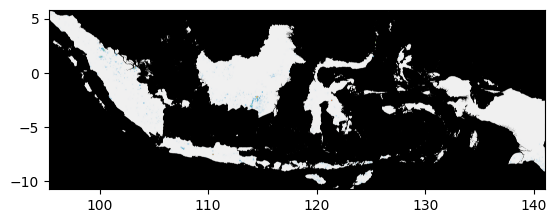

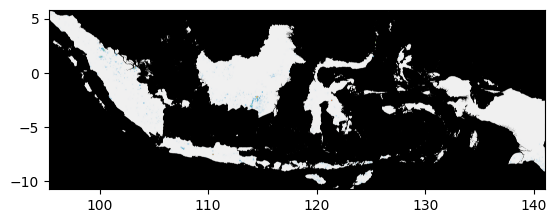

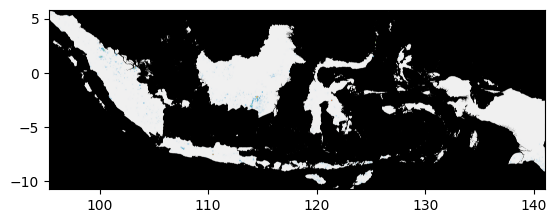

<Axes: >

In [20]:
# Display individual layers
show(fh_2001,1)
show(fh_2001,2)
show(fh_2001,3)

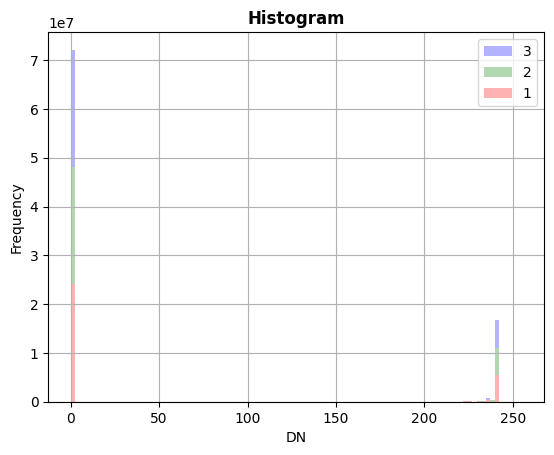

In [49]:
from rasterio.plot import show_hist

show_hist(fh_2001, 
          bins=100,
          lw=0.0, 
          stacked=True, 
          alpha=0.3,
          histtype='stepfilled', 
          title="Histogram")

#### Load all rasters as xarray

In [41]:
def load_yearly_rasters_rio(years, path_template="input-data/fire-history-data/kd{year}_rgb.tif"):
    """
    Load raster layers from different years and combine
    them into xarray object, with full spatial metadata preserved.

    Input:
    -----
    years : list or range
        years to load (e.g., range(2001, 2016))
    path_template : str
        path template with {year} placeholder

    Output:
    ------
    combined: xarray
        combined raster layers (yearly temporal resolution)
    """
    
    datasets = []
    
    for year in years:
        filepath = path_template.format(year=year)
        da = rioxarray.open_rasterio(filepath, masked=True)
        #da = da.squeeze('band', drop=True)  # Remove band dimension if single band
        da = da.assign_coords(time=year)
        datasets.append(da)
    
    # concatenate along time dimension
    combined = xr.concat(datasets, dim='time')
    return combined

# function developed by Claude AI

In [47]:
fh = load_yearly_rasters_rio(years=range(2001,2003))

In [44]:
rioxarray.open_rasterio("fire-history-data/kd2001_rgb.tif", masked=True)

<xarray.DataArray (band: 3, y: 3306, x: 9133)> Size: 362MB
[90581094 values with dtype=float32]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 73kB 95.35 95.35 95.36 95.36 ... 141.0 141.0 141.0
  * y            (y) float64 26kB 5.808 5.803 5.798 ... -10.71 -10.71 -10.72
    spatial_ref  int64 8B 0
Attributes:
    DataType:       Processed
    AREA_OR_POINT:  Area
    BandName:       Band_1
    scale_factor:   1.0
    add_offset:     0.0

Problem with this dataset: it is an RGB image, it does not show the actual data (how many fires) but only the color based on the category. Therefore, it is better to use the original data (see next section).

# MODIS fire alerts from NASA FIRMS
Indonesia, 2001 to 2025

attribute documentation [here](https://www.earthdata.nasa.gov/data/tools/firms/active-fire-data-attributes-modis-viirs)

In [41]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [19]:
modis_fa_path = "input-data/nasa-firms-modis-fire-alerts/fire_archive_M-C61_697841.shp"

In [20]:
modis_fa = gpd.read_file(modis_fa_path)

In [21]:
# filter to only keep TYPE 0 (presumed vegetation fire, not volcano activity etc.)
modis_fa_vf = modis_fa[modis_fa["TYPE"] == 0].copy()

In [22]:
# add column with year and month
modis_fa_vf.loc[:,"YEAR"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=1).str[0].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

modis_fa_vf.loc[:,"MONTH"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=2).str[1].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

In [23]:
modis_fa_vf.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,YEAR,MONTH
0,-4.0082,121.7859,312.0,2.3,1.5,2001-01-01,0258,Terra,MODIS,57,6.03,291.7,22.9,D,0,POINT (121.7859 -4.0082),2001,1
1,-8.4164,117.5434,320.0,1.3,1.1,2001-01-01,0259,Terra,MODIS,39,6.03,305.8,13.1,D,0,POINT (117.5434 -8.4164),2001,1
5,-8.8759,120.7638,314.9,2.6,1.6,2001-01-02,0204,Terra,MODIS,0,6.03,296.0,28.8,D,0,POINT (120.7638 -8.8759),2001,1
8,-8.2273,123.8952,312.5,2.2,1.4,2001-01-03,0247,Terra,MODIS,0,6.03,286.4,17.1,D,0,POINT (123.8952 -8.2273),2001,1
13,0.0546,101.7350,312.4,1.5,1.2,2001-01-05,0411,Terra,MODIS,60,6.03,284.5,12.7,D,0,POINT (101.735 0.0546),2001,1


2966527


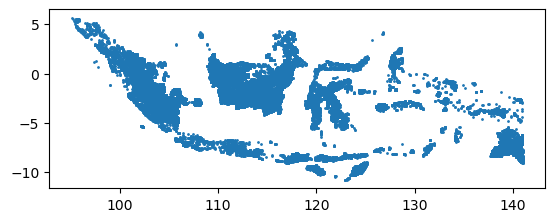

In [40]:
# plot fires in 2015
modis_fa_vf_2015 = modis_fa_vf[modis_fa_vf["YEAR"] == 2015]

print(modis_fa_vf_2015.size)

modis_fa_vf_2015.plot(markersize=1)
plt.show()

In [27]:
# add column with confidence classification
modis_fa_vf['HIGH_CONFIDENCE'] = np.where(modis_fa_vf['CONFIDENCE'] >= 70, True, False)

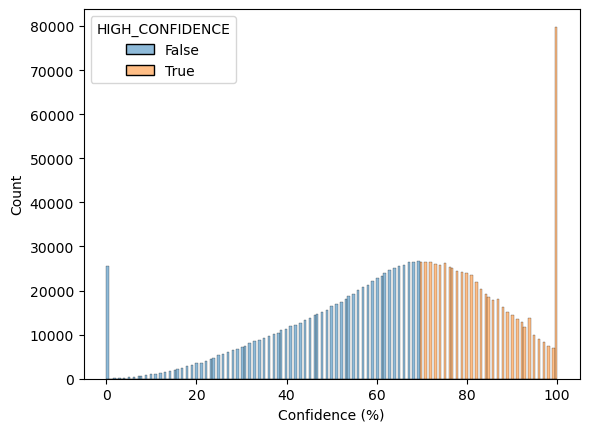

In [28]:
# check distribution of confidence
sns.histplot(x="CONFIDENCE", hue="HIGH_CONFIDENCE", data=modis_fa_vf)
plt.xlabel("Confidence (%)")
plt.show()

In [30]:
values = np.arange(2000,2026,1)
labels = np.arange(2000,2026,1)[::5] # only every fifth
labels = np.where(np.isin(values, labels), values, "")

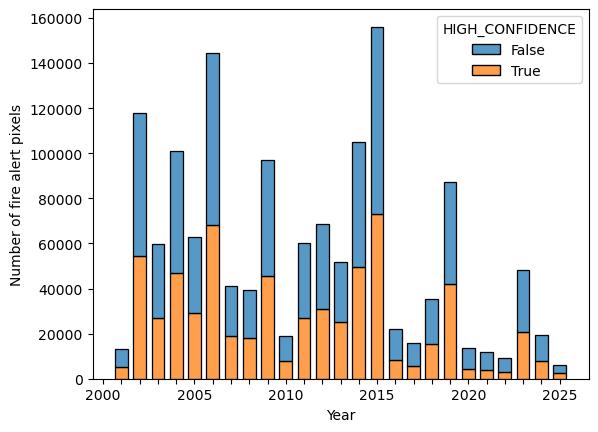

In [31]:
# check nr of fires per year
sns.histplot(x="YEAR", 
             hue="HIGH_CONFIDENCE", multiple="stack", 
             data=modis_fa_vf,
             discrete=True,
             #binwidth=.5, 
             shrink=.7)

plt.xticks(values, labels=labels)

plt.xlabel("Year")
plt.ylabel("Number of fire alert pixels")

plt.show()

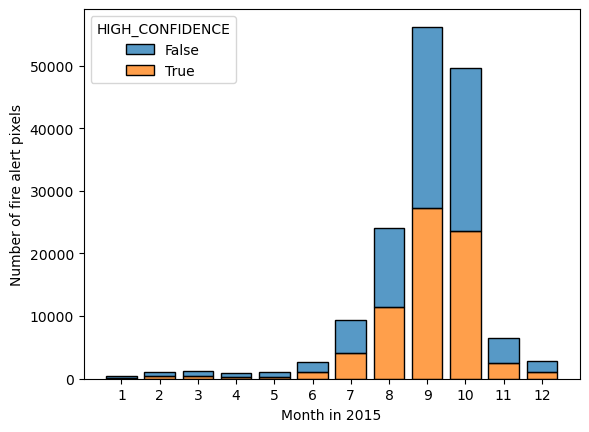

In [32]:
# check fires per month in 2015
modis_fa_2015 = modis_fa_vf[modis_fa_vf.YEAR == 2015]

sns.histplot(x="MONTH", 
             hue="HIGH_CONFIDENCE",
             multiple="stack", discrete=True,
             shrink=.8,
             data=modis_fa_2015)

plt.xticks(np.arange(1,13,1))

plt.xlabel("Month in 2015")
plt.ylabel("Number of fire alert pixels")

plt.show()

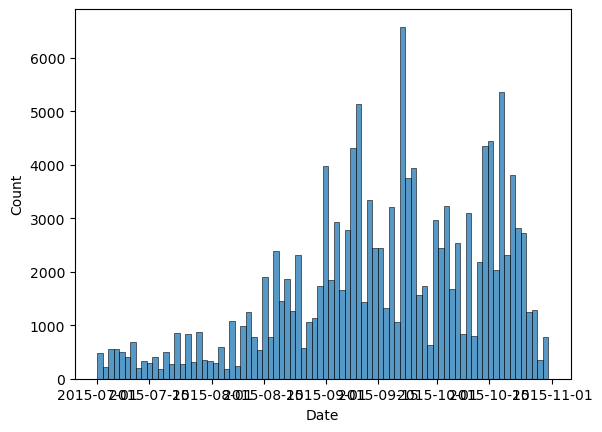

In [33]:
# check fires per month in 2015
modis_fa_2015_fs = modis_fa_2015[modis_fa_2015.MONTH.between(7,10)]

sns.histplot(x="ACQ_DATE", data=modis_fa_2015_fs)
plt.xlabel("Date")
plt.show()

In [39]:
# subset to before, during, and after fire detection period

start_date = '2015-08-01'
end_date = '2015-10-31'

fires_before = modis_fa_vf[modis_fa_vf.ACQ_DATE < start_date]
fires_summer_2015 = modis_fa_vf[modis_fa_vf.ACQ_DATE.between(start_date,end_date)]
fires_after = modis_fa_vf[modis_fa_vf.ACQ_DATE > end_date]

### Selection by buffer

In [58]:
# reproject to Web Mercator (in m)
modis_fa_vf_reproj = modis_fa_vf.copy().to_crs('EPSG:3857')

# replace geometry with buffer 
modis_fa_vf_reproj['geometry'] = modis_fa_vf_reproj.geometry.buffer(
    distance=500,       # meters
    cap_style="square"  # shape of buffer
)

In [66]:
modis_fa_vf_reproj2015 = modis_fa_vf_reproj[modis_fa_vf_reproj["YEAR"] == 2015]
modis_fa_vf_reproj_after2015 = modis_fa_vf_reproj[modis_fa_vf_reproj["YEAR"] > 2015]

only_2015 = modis_fa_vf_reproj2015.geometry.difference(modis_fa_vf_reproj_after2015.geometry, align=False)

print(only_2015.size)

only_2015.plot()

ValueError: Lengths of inputs do not match. Left: 156133, Right: 268590

# Indonesia boundaries

In [70]:
import geopandas as gpd

filepath_boundaries = 'input-data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp'

# Get country borders at different resolutions
countries = gpd.read_file(filepath_boundaries)

# This gives you a GeoDataFrame with country polygons
countries.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,Bolivia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,Peru,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


In [71]:
indonesia = countries[countries.ADMIN == 'Indonesia']

<Axes: >

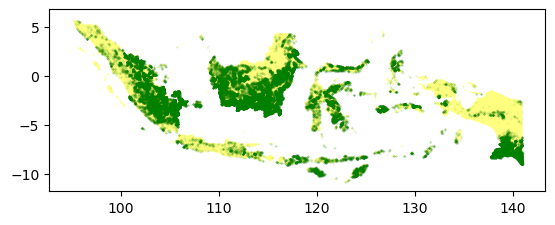

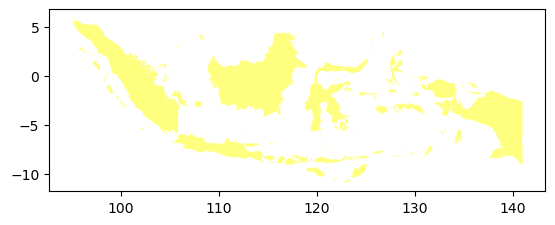

In [72]:
ax = indonesia.plot(color='yellow', alpha=.5)
modis_fa_vf_2015.plot(ax=ax, markersize=0.1, color='green',alpha=.1)

indonesia.plot(color='yellow', alpha=.5)

In [73]:
fires_outside = fires_summer_2015[~fires_summer_2015.geometry.within(indonesia.geometry.union_all())]

<Axes: >

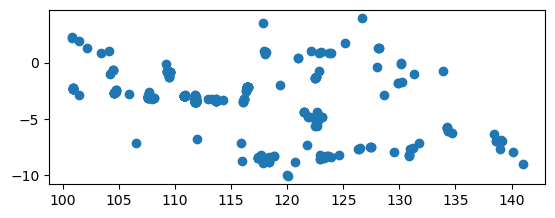

In [74]:
fires_outside.plot()

In [75]:
len(fires_outside)

305

# Indonesian peat lands

### Global Forest Watch (no longer used due to outdated/poor data)

In [82]:
filepath_peatlands = "input-data/indonesia-peatlands/Indonesia_Peat_Lands.shp"
peatlands = gpd.read_file(filepath_peatlands)

In [83]:
peatlands.head()

,objectid_1,objectid,layer_revi,shape_leng,globalid,shape_Le_1,shape_Area,geometry
0,1,482,gambut,70789.064321,{DF27C432-2805-4FCF-8A7E-7E1DFD125C87},72528.694951,3.286301e+07,"MULTIPOLYGON Z (((14845286.338 -394955.138 0, ..."
1,2,483,gambut,3013.842302,{03DD8438-E728-49A1-9DEB-5997D38E1657},2996.905854,5.275723e+05,"POLYGON Z ((14893124.535 -393987.592 0, 148928..."
2,3,484,gambut,5750.073144,{356A5BD6-C249-4485-BB25-C99B383A708C},5635.047284,1.321287e+06,"POLYGON Z ((14797350.914 -393724.104 0, 147973..."
3,4,485,gambut,2027.459326,{0159915D-83EB-4B7C-AF71-AA67029CB67E},1912.760954,8.390727e+04,"POLYGON Z ((14891358.237 -393201.229 0, 148914..."
4,5,486,gambut,178017.496343,{82E80B91-9343-44BE-B9D5-119AD8FAE5C9},176121.923929,2.474371e+08,"POLYGON Z ((15554582.332 -395133.063 0, 155547..."


<Axes: >

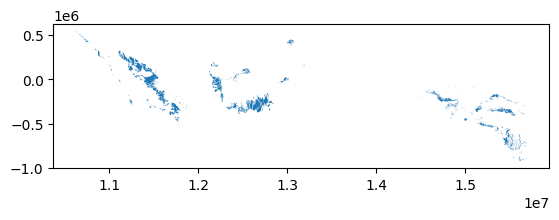

In [84]:
peatlands.plot(column="layer_revi")

### Global Peatlands

In [70]:
import rioxarray as rxr
import rasterio 
import numpy as np

In [66]:
# load data as xarray
filepath_gp = "input-data/global-peatland-map/peatGPA22WGS_2cl.tif"
peatland = rxr.open_rasterio(filepath_gp)

# subset to Indonesia
peatland = peatland.sel(x=slice(94,143), y=slice(1,-14))

In [42]:
# import as raster (probably unnecessary)
filepath_gp = "input-data/global-peatland-map/peatGPA22WGS_2cl.tif"
peatland_r = rasterio.open(filepath_gp)

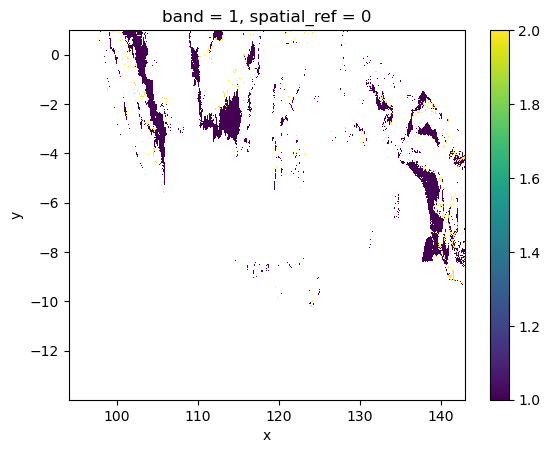

In [83]:
# set 255 (no peatland) to NaN
peatland_only = peatland.where(peatland != 255, other=np.nan)

peatland_only.plot()
plt.show()

In [45]:
# Check basic information
print("Number of bands:", peatland_r.count)
print("Width (nr of pixels):", peatland_r.width)
print("Height (nr of pixels):", peatland_r.height)
print("CRS:", peatland_r.crs)
print("Bounding coordinates:", peatland_r.bounds)

Number of bands: 1
Width (nr of pixels): 36017
Height (nr of pixels): 15295
CRS: EPSG:4326
Bounding coordinates: BoundingBox(left=-179.766242816, bottom=-74.342809401, right=179.733393112, top=78.32251340541809)


In [47]:
np.unique(peatland_r.read(1))

array([  1,   2, 255], dtype=uint8)

# Land cover

In [15]:
import rasterio
from rasterio.plot import show
import rioxarray as rxr
import xarray as xr

In [2]:
lc_example = rasterio.open('input-data/ESA_IndonesiaCover/MAP/ESA_WorldCover_10m_2021_v200_N00E093_Map/ESA_WorldCover_10m_2021_v200_N00E093_Map.tif')
                           

In [4]:
# Check basic information
print("Number of bands:", lc_example.count)
print("Width (nr of pixels):", lc_example.width)
print("Height (nr of pixels):", lc_example.height)
print("CRS:", lc_example.crs)
print("Bounding coordinates:", lc_example.bounds)

Number of bands: 1
Width (nr of pixels): 36000
Height (nr of pixels): 36000
CRS: EPSG:4326
Bounding coordinates: BoundingBox(left=93.0, bottom=0.0, right=96.0, top=3.0)


In [ ]:
filepath_gp
lc_example_xr = rxr.open_rasterio()


In [2]:
import os

In [17]:
# set up empty xarray
lc = xr.Dataset()

path_lc_dirs = 'input-data/ESA_IndonesiaCover/MAP/'
directories = os.listdir(path_lc_dirs)

for d in directories:
    file = os.listdir(f"{path_lc_dirs}/{d}")[0]
    filepath = f"{path_lc_dirs}/{d}/{file}"
    
    # read file as xarray
    new_lc = rxr.open_rasterio(filepath)

    # add to complete xarray
    lc = xr.concat([lc, new_lc], dim=)



TypeError: concat() missing 1 required positional argument: 'dim'